# 009 Interrupts

这是 LangGraph 学习线的第九份 Notebook。

官方参考：

- https://docs.langchain.com/oss/python/langgraph/interrupts

学习目标：

1. 理解 `interrupt()` 为什么必须配合 checkpointer 和 `thread_id`
2. 学会从 `__interrupt__` 中读取暂停请求
3. 学会用 `Command(resume=...)` 恢复同一个 graph thread
4. 跑通审批、拒绝、人工编辑、输入校验四种 human-in-the-loop 模式
5. 理解节点恢复时会从节点开头重新执行的副作用风险
6. 学会把 interrupt 映射成 Harness 风格审批事件

## 1. Interrupt 解决什么问题

有些 agent 流程不能自己一路跑到底。

例如：

- 删除数据前需要人工审批
- 发送邮件前需要人工确认
- 模型生成草稿后需要人工编辑
- 用户输入不合法时需要再次追问

`interrupt()` 的作用就是：

```text
暂停 graph，保存 checkpoint，把问题抛给外部系统，等待外部输入后继续。
```

它不是普通 Python `input()`，因为它不会阻塞当前进程等人输入，而是把运行状态保存下来，让服务端可以稍后恢复。

In [18]:
import importlib.metadata
import json
from typing import Literal

from langgraph.checkpoint.memory import InMemorySaver
from langgraph.graph import END, START, StateGraph
from langgraph.types import Command, interrupt
from typing_extensions import TypedDict

print("langgraph", importlib.metadata.version("langgraph"))

langgraph 1.2.1


## 2. 最小审批 graph

这个 graph 做三件事：

```text
START -> approval -> proceed/cancel -> END
```

`approval` 节点会调用 `interrupt()`。

恢复时：

```python
Command(resume=True)
```

这个 `True` 会变成 `interrupt()` 的返回值。

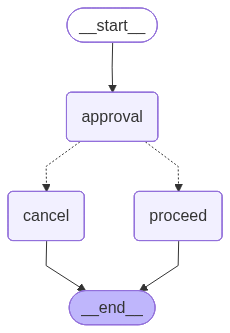

In [ ]:
class ApprovalState(TypedDict):
    action_details: str
    status: str
    approved: bool | None


approval_runs = {"count": 0}


def approval_node(state: ApprovalState) -> Command[Literal["proceed", "cancel"]]:
    approval_runs["count"] += 1
    print("approval node run count:", approval_runs["count"])

    decision = interrupt(
        {
            "kind": "approval_required",
            "question": "是否批准这个动作？",
            "details": state["action_details"],
            "run_count_before_interrupt": approval_runs["count"],
        }
    )

    print("approval decision after resume:", decision)
    return Command(
        goto="proceed" if decision else "cancel",
        update={"approved": bool(decision)},
    )


def proceed_node(state: ApprovalState) -> dict:
    return {"status": "approved"}


def cancel_node(state: ApprovalState) -> dict:
    return {"status": "rejected"}


approval_builder = StateGraph(ApprovalState)
approval_builder.add_node("approval", approval_node)
approval_builder.add_node("proceed", proceed_node)
approval_builder.add_node("cancel", cancel_node)

approval_builder.add_edge(START, "approval")
approval_builder.add_edge("proceed", END)
approval_builder.add_edge("cancel", END)

approval_graph = approval_builder.compile(checkpointer=InMemorySaver())
approval_graph

## 3. 第一次执行：命中 interrupt

当前环境是 `langgraph==1.1.9`。

官方新版文档推荐 `stream_events(..., version="v3")`，但本环境没有同步 `stream_events`。

所以本课使用默认 `invoke()` API：interrupt 信息会出现在返回值的 `__interrupt__` 字段里。

In [20]:
approval_config = {"configurable": {"thread_id": "interrupt-approval-demo"}}

first_result = approval_graph.invoke(
    {
        "action_details": "删除用户 user-42 的测试数据",
        "status": "pending",
        "approved": None,
    },
    approval_config,
)

interrupts = first_result.get("__interrupt__", [])
print("result keys:", sorted(first_result.keys()))
print("interrupt value:", interrupts[0].value)
print("interrupt id:", interrupts[0].id)

snapshot = approval_graph.get_state(approval_config)
print("snapshot values:", snapshot.values)
print("snapshot next:", snapshot.next)
print("snapshot step:", snapshot.metadata.get("step"))

approval node run count: 1
result keys: ['__interrupt__', 'action_details', 'approved', 'status']
interrupt value: {'kind': 'approval_required', 'question': '是否批准这个动作？', 'details': '删除用户 user-42 的测试数据', 'run_count_before_interrupt': 1}
interrupt id: f2be724c9e76d504cec9d154fb394665
snapshot values: {'action_details': '删除用户 user-42 的测试数据', 'status': 'pending', 'approved': None}
snapshot next: ('approval',)
snapshot step: 0


## 4. 用同一个 thread_id 恢复

恢复时必须继续使用同一个 `thread_id`：

```python
Command(resume=True)
```

这里的 `True` 会回到 `approval_node` 里，成为：

```python
decision = interrupt(...)
```

这一行的返回值。

注意：恢复时会从 `approval_node` 开头重新执行，所以你会看到 run count 增加。

In [21]:
approved_result = approval_graph.invoke(
    Command(resume=True),
    approval_config,
)

print("approved result:", approved_result)
print("approval node total runs:", approval_runs["count"])

final_snapshot = approval_graph.get_state(approval_config)
print("final next:", final_snapshot.next)
print("final step:", final_snapshot.metadata.get("step"))

approval node run count: 2
approval decision after resume: True
approved result: {'action_details': '删除用户 user-42 的测试数据', 'status': 'approved', 'approved': True}
approval node total runs: 2
final next: ()
final step: 2


## 5. 拒绝分支

`Command(resume=False)` 会让审批节点走 `cancel` 分支。

In [ ]:
reject_config = {"configurable": {"thread_id": "interrupt-reject-demo"}}

reject_first = approval_graph.invoke(
    {
        "action_details": "向外部系统提交高风险变更",
        "status": "pending",
        "approved": None,
    },
    reject_config,
)
print("reject interrupt:", reject_first["__interrupt__"][0].value)

reject_final = approval_graph.invoke(Command(resume=False), reject_config)
print("reject final:", reject_final)

## 6. Review and edit：人工编辑 state

interrupt 的返回值不一定是 `True/False`。

也可以是人类编辑后的文本、对象、表单数据。

In [ ]:
class ReviewState(TypedDict):
    generated_text: str


def review_node(state: ReviewState) -> dict:
    edited_text = interrupt(
        {
            "kind": "review_and_edit",
            "instruction": "请审核并编辑下面的文本",
            "content": state["generated_text"],
        }
    )
    return {"generated_text": edited_text}


review_graph = (
    StateGraph(ReviewState)
    .add_node("review", review_node)
    .add_edge(START, "review")
    .add_edge("review", END)
    .compile(checkpointer=InMemorySaver())
)

review_config = {"configurable": {"thread_id": "interrupt-review-demo"}}
review_first = review_graph.invoke(
    {"generated_text": "这是一个需要人工润色的草稿。"},
    review_config,
)
print("review request:", review_first["__interrupt__"][0].value)

review_final = review_graph.invoke(
    Command(resume="这是人工审核并润色后的最终文本。"),
    review_config,
)
print("review final:", review_final)

## 7. Validating human input：输入不合法就再次 interrupt

一个节点里可以多次调用 `interrupt()`。

下面用一个年龄表单演示：

1. 第一次询问年龄
2. 用户给了非法值
3. graph 再次 interrupt，提示重新输入
4. 用户给了合法值，节点结束

In [ ]:
class FormState(TypedDict):
    age: int | None


def collect_age(state: FormState) -> dict:
    prompt = "请输入年龄"

    while True:
        answer = interrupt(prompt)

        if isinstance(answer, int) and answer > 0:
            return {"age": answer}

        prompt = repr(answer) + " 不是有效年龄，请输入正整数"


form_graph = (
    StateGraph(FormState)
    .add_node("collect_age", collect_age)
    .add_edge(START, "collect_age")
    .add_edge("collect_age", END)
    .compile(checkpointer=InMemorySaver())
)

form_config = {"configurable": {"thread_id": "interrupt-form-demo"}}

form_first = form_graph.invoke({"age": None}, form_config)
print("first prompt:", form_first["__interrupt__"][0].value)

form_second = form_graph.invoke(Command(resume="thirty"), form_config)
print("second prompt:", form_second["__interrupt__"][0].value)

form_final = form_graph.invoke(Command(resume=30), form_config)
print("form final:", form_final)

## 8. Streaming 中观察 interrupt

当前环境虽然没有同步 `stream_events(..., version="v3")`，但可以通过 `stream(..., stream_mode="values", version="v2")` 看到 values stream part 上的 `interrupts` 字段。

这可以帮助你把内部 interrupt 转成前端事件。

In [ ]:
stream_config = {"configurable": {"thread_id": "interrupt-stream-demo"}}

for part in approval_graph.stream(
    {
        "action_details": "通过 streaming 观察审批中断",
        "status": "pending",
        "approved": None,
    },
    config=stream_config,
    stream_mode="values",
    version="v2",
):
    print("type=", part["type"])
    print("data=", part["data"])
    print("interrupts=", part.get("interrupts"))

## 9. 映射成 Harness 风格审批事件

前端通常不应该直接理解 LangGraph 的内部对象。

可以把 interrupt 转成业务事件：

```text
Interrupt(value={...}, id="...")
->
event: approval_required
data: {"ticket_id": "...", "payload": {...}}
```

In [ ]:
def interrupt_to_sse(interrupt_obj) -> str:
    payload = {
        "ticket_id": interrupt_obj.id,
        "payload": interrupt_obj.value,
    }
    return "event: approval_required\n" + "data: " + json.dumps(payload, ensure_ascii=False) + "\n"


sse_demo = interrupt_to_sse(interrupts[0])
print(sse_demo)

## 10. Interrupt 规则

官方文档里最重要的规则：

| 规则 | 原因 |
| --- | --- |
| 不要把 `interrupt()` 包在裸 `try/except` 里 | interrupt 通过特殊异常暂停，裸捕获会吞掉暂停信号 |
| 同一个节点内多个 interrupt 的顺序要稳定 | 恢复值按 interrupt 顺序匹配 |
| interrupt payload 要 JSON 可序列化 | durable checkpointer 需要落库 |
| `interrupt()` 前面的副作用要幂等 | 恢复时节点会从开头重新执行 |
| 恢复必须使用同一个 `thread_id` | `thread_id` 是 checkpoint 游标 |
| `Command(resume=...)` 才是恢复 interrupt 的输入模式 | `Command(update/goto/graph)` 主要用于节点返回 |

尤其注意这一条：

```text
resume 不是从 interrupt 那一行继续，
而是从调用 interrupt 的节点开头重新执行。
```

## 11. 本讲练习

请判断下面设计是否安全：

```python
def approve_payment(state):
    payment_id = db.create_payment(state["amount"])
    approved = interrupt("是否付款？")
    if approved:
        db.pay(payment_id)
    return {"status": "done"}
```

参考答案：不安全。

`db.create_payment(...)` 在 `interrupt()` 前面，恢复时节点会从开头重新执行，可能重复创建 payment。

更安全的做法：

- `create_payment` 做成幂等 upsert
- 或把审批和创建付款拆成两个节点
- 或先 interrupt，批准后再创建付款

## 12. 本讲小结

这一讲的核心：

```text
Interrupt = checkpoint + 暂停请求 + 外部输入 + 同 thread 恢复。
```

你现在应该能看懂：

- `interrupt(payload)`
- `__interrupt__`
- `Command(resume=...)`
- 为什么必须有 checkpointer
- 为什么必须复用同一个 `thread_id`
- 为什么 interrupt 前的副作用要幂等
- 如何把 interrupt 转成审批 SSE

下一讲可以继续学习 Time Travel。